# HW 4 - Rituraj Harish Navindgikar

In [1]:
import os
import matplotlib.pyplot as plt

import cv2
import numpy as np

import plotly.graph_objects as go

import gtsam

### Load Images

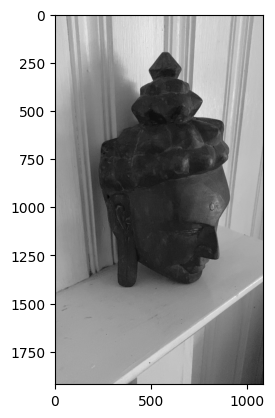

In [2]:
images_path = sorted(os.listdir("images"))

not_normalized_image = []

for img in images_path:
    not_normalized_image.append(cv2.imread("images/" + img, cv2.IMREAD_GRAYSCALE))

plt.imshow(not_normalized_image[0], cmap='gray')

### Normalize images

Normalized Image


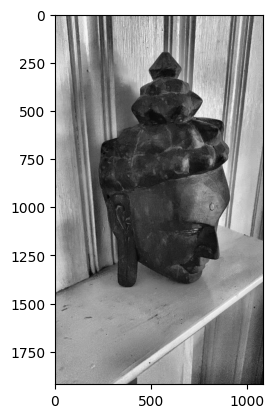

Not Normalized Image


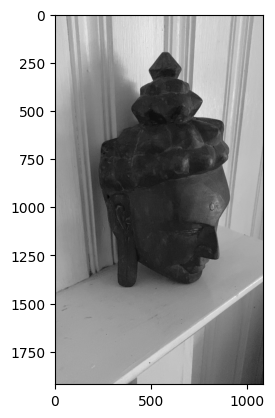

In [ ]:
def normalize_images(images):

    normalized = []
    for img in images:
        # CLAHE for local contrast + z-score for scale invariance
        clahe = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(8,8))
        g = clahe.apply(img)
        g = g.astype(np.float32)
        mu, sigma = np.mean(g), np.std(g) + 1e-6
        g = (g - mu) / sigma
        g = cv2.normalize(g, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        normalized.append(g)

    return normalized

image_data = normalize_images(not_normalized_image)

print("Normalized Image")
plt.imshow(image_data[0], cmap='gray')
plt.show()

print("Not Normalized Image")
plt.imshow(not_normalized_image[0], cmap='gray')

## Testing on 2 images for now

### Feature Detector, Descriptor and Matching

In [ ]:
def apply_non_max_suppression_grid(keypoints, image_shape, grid_size=8, max_per_cell=50):
    h, w = image_shape
    cell_h, cell_w = h // grid_size, w // grid_size
    
    # grid to store keypoints
    grid = [[[] for _ in range(grid_size)] for _ in range(grid_size)]
    
    # assign keypoints ->> grid cells
    for kp in keypoints:
        x, y = int(kp.pt[0]), int(kp.pt[1])
        grid_x = min(x // cell_w, grid_size - 1)
        grid_y = min(y // cell_h, grid_size - 1)
        grid[grid_y][grid_x].append(kp)
    
    # keeping only top keypoints per cel
    filtered_keypoints = []
    for row in grid:
        for cell in row:
            if cell:
                cell.sort(key=lambda kp: kp.response, reverse=True)
                filtered_keypoints.extend(cell[:max_per_cell])
    
    return filtered_keypoints

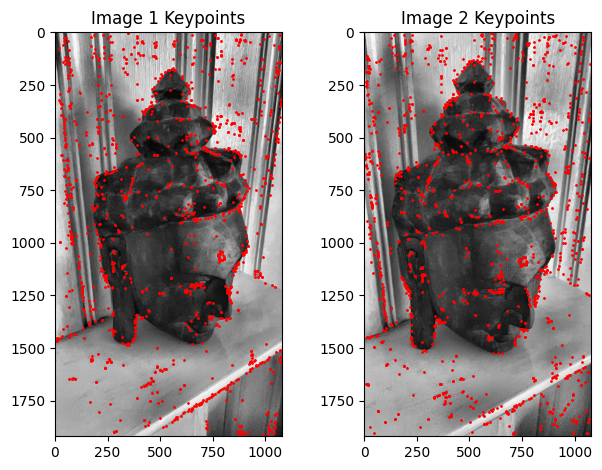

In [5]:
# using SIFT and BFF
class DetectionAndMatching:
    def __init__(self, n_features=4000):
        # sift for descriptor and keypoint
        self.sift = cv2.SIFT_create(nfeatures=n_features, nOctaveLayers=4)
        
        # brute force for matching
        self.matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

    @staticmethod
    def create_statue_mask(img, cx_ratio=0.53, cy_ratio=0.43, w_ratio=0.65, h_ratio=0.62):
        h, w = img.shape[:2]
        center = (int(w * cx_ratio), int(h * cy_ratio))
        axes = (int(w * w_ratio / 2), int(h * h_ratio / 2))  # (width, height)

        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.ellipse(mask, center, axes, 0, 0, 360, 255, -1)
        return mask

    def sift_detection(self, img, cx_ratio, disable_roi, h_ratio=0.62, w_ratio=0.65, cy_ratio=0.43):
        if disable_roi:
            mask = None
        else:
            # Create a mask for the statue region
            mask = DetectionAndMatching.create_statue_mask(img, cx_ratio, h_ratio=h_ratio, w_ratio=w_ratio, cy_ratio=cy_ratio)

        keypoints, descriptor = self.sift.detectAndCompute(img, mask)
        
        # Apply non-max suppression for even distribution
        keypoints = apply_non_max_suppression_grid(keypoints, img.shape, grid_size=8, max_per_cell=25)
        
        # Recompute descriptors for filtered keypoints
        keypoints, descriptor = self.sift.compute(img, keypoints)
        
        return keypoints, descriptor
        
    def brute_force_matching(self, img1_desc, img2_desc, thresh=0.65):
        matches = self.matcher.knnMatch(img1_desc, img2_desc, k=2)
        
        # Lowe's ratio test
        good_matches = []
        for match_pair in matches:
            if len(match_pair) == 2:
                m, n = match_pair
                if m.distance < thresh * n.distance:
                    good_matches.append(m)

        return good_matches

img1 = image_data[4]
img2 = image_data[5]

disable_roi = True
features = DetectionAndMatching()
kp1, des1 = features.sift_detection(img1, cx_ratio=0.53, h_ratio=0.62, disable_roi=disable_roi) # 0.53 for img1, should be reaching 0.33 for img 23 as our ROI changes
kp2, des2 = features.sift_detection(img2, cx_ratio=0.53, h_ratio=0.62, disable_roi=disable_roi)

matches = features.brute_force_matching(des1, des2)

# creating mask again for 
if disable_roi:
    mask = None
else:
    mask = features.create_statue_mask(img1)

plt.subplot(1, 2, 1)
plt.imshow(img1, cmap='gray')
plt.scatter([kp.pt[0] for kp in kp1], [kp.pt[1] for kp in kp1], s=1, c='r', label='Keypoints')
if not disable_roi:
    plt.contour(mask, colors='b', linewidths=0.5)
    plt.plot([], [], color='b', linewidth=0.5, label='ROI')
else:
    plt.title('Image 1 Keypoints')
# plt.legend()

plt.subplot(1, 2, 2)
plt.imshow(img2, cmap='gray')
plt.scatter([kp.pt[0] for kp in kp2], [kp.pt[1] for kp in kp2], s=1, c='r', label='Keypoints')
if not disable_roi:
    plt.contour(mask, colors='b', linewidths=0.5)
    plt.plot([], [], color='b', linewidth=0.5, label='ROI')
    plt.title('Image 2 Keypoints & ROI')
else:
    plt.title('Image 2 Keypoints')
# plt.legend()

plt.tight_layout()
plt.show() 


### Draw Matches

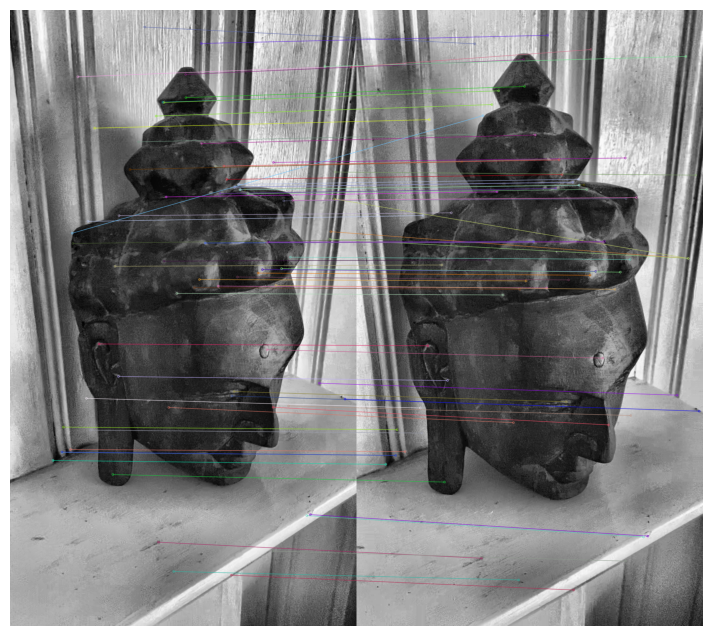

In [6]:
def draw_matches(img1, img2, kp1, kp2, matches):
    img = cv2.drawMatches(img1, kp1, img2, kp2, matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.figure(figsize=(15, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

draw_matches(img1, img2, kp1, kp2, matches)

### Fundamental Matrix

In [ ]:
def normalize_points(pts):
    """Hartley normalization with transformation matrix"""
    pts = pts.astype(np.float64)  
    centroid = np.mean(pts, axis=0)
    pts_centered = pts - centroid
    
    # mean distance from origin
    distances = np.linalg.norm(pts_centered, axis=1)
    mean_distance = np.mean(distances[distances > 0]) 
    scale = np.sqrt(2) / max(mean_distance, 1e-8)
    
    # Normalization transformation matrix
    T = np.array([[scale, 0, -scale*centroid[0]],
                  [0, scale, -scale*centroid[1]],
                  [0, 0, 1]], dtype=np.float64)
    
    # apply transformation
    pts_homo = np.column_stack([pts, np.ones(len(pts))])
    pts_norm = (T @ pts_homo.T).T
    
    return pts_norm[:, :2], T

def fundamental_matrix(kp1, kp2, matches, thresh=3.0, max_iters=1000):
    # 8 dof
    if(len(matches) < 8):
        print("Less than 8 matches!!!")
        return None, None
    
    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 2)
    
    best_F = None
    best_inliers = []
    best_inlier_count = 0
    
    for _ in range(max_iters):
        # Sample 8 random points
        sample_indices = np.random.choice(len(matches), 8, replace=False)
        sample_src = src_pts[sample_indices]
        sample_dst = dst_pts[sample_indices]
        
        # Normalize sample points
        src_norm, T1 = normalize_points(sample_src)
        dst_norm, T2 = normalize_points(sample_dst)
        
        # Build A matrix for 8-point algorithm
        A = np.zeros((8, 9))
        for i in range(8):
            x1, y1 = src_norm[i]
            x2, y2 = dst_norm[i]
            A[i] = [x2*x1, x2*y1, x2, y2*x1, y2*y1, y2, x1, y1, 1]
        
        # solving Af = 0
        _, _, Vt = np.linalg.svd(A)
        F_norm = Vt[-1].reshape(3, 3)
        
        # denormalize
        F_candidate = T2.T @ F_norm @ T1
        
        # make rank-2
        U, S, Vt = np.linalg.svd(F_candidate)
        S[-1] = 0
        F_candidate = U @ np.diag(S) @ Vt
        
        # count inliers using ALL points
        inliers = []
        for i in range(len(matches)):
            x1 = np.array([src_pts[i][0], src_pts[i][1], 1])
            x2 = np.array([dst_pts[i][0], dst_pts[i][1], 1])
            
            # proper epipolar line distance
            line1 = F_candidate @ x1 
            line2 = F_candidate.T @ x2  
            
            dist1 = abs(x2.T @ F_candidate @ x1) / np.sqrt(line1[0]**2 + line1[1]**2)
            dist2 = abs(x1.T @ F_candidate.T @ x2) / np.sqrt(line2[0]**2 + line2[1]**2)
            
            error = (dist1 + dist2) / 2
            
            if error < thresh:
                inliers.append(i)
        
        if len(inliers) > best_inlier_count:
            best_inlier_count = len(inliers)
            best_F = F_candidate.copy()
            best_inliers = [matches[i] for i in inliers]
            
            # early termination check
            # inlier_ratio = len(inliers) / len(matches)
            # if inlier_ratio > confidence:
            #     break
    if best_inlier_count >= 8:
        return best_F, best_inliers, src_norm, dst_norm

    print("Returning Empty F matrix!!!")
    return None, None

In [8]:
F, _, src_norm, dst_norm = fundamental_matrix(kp1, kp2, matches)
print("Fundamental Matrix:\n", F)

Fundamental Matrix:
 [[ 2.04434296e-08  3.69172991e-07 -5.13741307e-04]
 [-2.55382582e-07 -1.76261566e-08 -1.95812160e-03]
 [ 4.69463388e-04  2.07640704e-03 -1.26984989e-01]]


### Check Epipolar lines

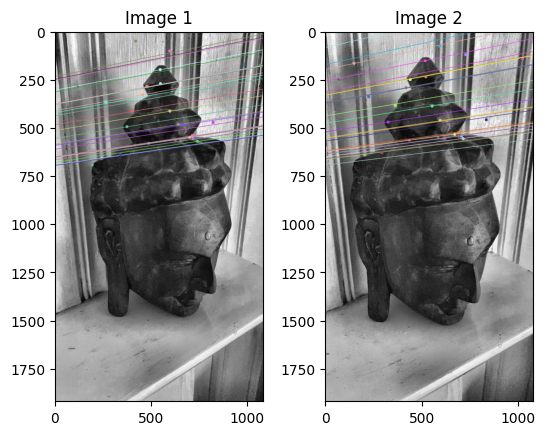

In [9]:
def draw_epipolar_lines(F, img1, img2, pts1, pts2):
    lines1 = cv2.computeCorrespondEpilines(pts2.reshape(-1,1,2), 2, F).reshape(-1,3)
    lines2 = cv2.computeCorrespondEpilines(pts1.reshape(-1,1,2), 1, F).reshape(-1,3)
    
    def draw(img, lines, pts):
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        h, w = img.shape[:2]
        for line, pt in zip(lines, pts):
            c = tuple(np.random.randint(50,255,3).tolist())
            x0, y0 = 0, int(-line[2]/line[1]) if abs(line[1]) > 1e-6 else (int(-line[2]/line[0]), 0)
            x1, y1 = w-1, int(-(line[2]+line[0]*(w-1))/line[1]) if abs(line[1]) > 1e-6 else (int(-line[2]/line[0]), h-1)
            cv2.line(img, (x0,y0), (x1,y1), c, 2)
            cv2.circle(img, tuple(map(int,pt)), 8, c, -1)
        return img
    
    return draw(img1.copy(), lines1, pts1), draw(img2.copy(), lines2, pts2)

src_pts = np.float32([kp1[m.queryIdx].pt for m in matches[:30]])
dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches[:30]])

img1_lines, img2_lines = draw_epipolar_lines(F, img1, img2, src_pts, dst_pts)

plt.subplot(1,2,1)
plt.imshow(img1_lines)
plt.title('Image 1')

plt.subplot(1,2,2)
plt.imshow(img2_lines)
plt.title('Image 2')
plt.show()

These epipolar lines are correct as there is slight movement between image 1 and image 2 in left side direction

### Essential Matrix

In [ ]:
def essential_matrix(F, K, src_pts, dst_pts):
    if F is None:
        return None, None, None

    K = K.astype(np.float64)
    F = F.astype(np.float64)
    
    E = K.T @ F @ K
    
    # SVD for E matrix
    U, S, Vt = np.linalg.svd(E)
    
    sigma = (S[0] + S[1]) / 2.0 
    S_corrected = np.array([sigma, sigma, 0])
    E_corrected = U @ np.diag(S_corrected) @ Vt
    
    # rotation matrices
    if np.linalg.det(U) < 0:
        U[:, -1] *= -1
    if np.linalg.det(Vt) < 0:
        Vt[-1, :] *= -1
        
    E_corrected = U @ np.diag(S_corrected) @ Vt
    
   # Extract R and t
    W = np.array([[0, -1, 0], 
                [1, 0, 0], 
                [0, 0, 1]], dtype=np.float64)

    # four configurations
    R1 = U @ W @ Vt
    R2 = U @ W @ Vt  
    R3 = U @ W.T @ Vt
    R4 = U @ W.T @ Vt

    C1 = U[:, 2]    # U(:,3) in 1-indexed notation
    C2 = -U[:, 2]   # -U(:,3)
    C3 = U[:, 2]
    C4 = -U[:, 2]

    t1 = -R1 @ C1
    t2 = -R2 @ C2
    t3 = -R3 @ C3
    t4 = -R4 @ C4

    solutions = [(R1, t1), (R2, t2), (R3, t3), (R4, t4)]
    
    # cheirality test
    best_solution = None
    max_good_points = 0
    
    for R, t_vec in solutions:
        # projection matrices
        P1 = K @ np.hstack([np.eye(3), np.zeros((3, 1))])
        P2 = K @ np.hstack([R, t_vec.reshape(3, 1)])
        
        good_count = 0
        test_points = min(len(src_pts), 100) 
        
        for i in range(test_points):
            try:
                # triangulate
                point_4d = cv2.triangulatePoints(
                    P1, P2, 
                    src_pts[i:i+1].T, 
                    dst_pts[i:i+1].T
                )
                
                if abs(point_4d[3, 0]) > 1e-8:
                    point_3d = point_4d[:3, 0] / point_4d[3, 0]
                    
                    # checking if point is in front of both cameras
                    depth1 = point_3d[2]
                    point_cam2 = R @ point_3d + t_vec
                    depth2 = point_cam2[2]
                    
                    if depth1 > 0.1 and depth2 > 0.1:
                        good_count += 1
                        
            except:
                continue
        
        if good_count > max_good_points:
            max_good_points = good_count
            best_solution = (R, t_vec.reshape(3, 1))
    
    if best_solution is None:
        print("Warning: No valid solution found, returning first option")
        return E_corrected, solutions[0][0], solutions[0][1].reshape(3, 1)
    
    return E_corrected, best_solution[0], best_solution[1]

## Fundamental and Essential Matrix for all images

In [ ]:
def process_fundamental_matrices(image_data, disable_roi):
    num_images = len(image_data)
    fundamental_results = []
    
    features = DetectionAndMatching()
    
    for i in range(num_images - 1):
        img1 = image_data[i]
        img2 = image_data[i + 1]
        
        cx_ratio_roi = (0.53 - i*0.009)  # Adjust cx_ratio for each image pair # 0.53
        cy_ratio_roi = (0.43 + i*0.002)  # Adjust cy_ratio for each image pair # 0.43
        w_ratio_roi = (0.65 + i*0.001)  # Adjust w_ratio for each image pair # 0.65
        h_ratio_roi = (0.67 + i*0.007)  # Adjust h_ratio for each image pair # 0.62

        kp1, des1 = features.sift_detection(img1, cx_ratio=cx_ratio_roi, h_ratio=h_ratio_roi, w_ratio=w_ratio_roi, cy_ratio=cy_ratio_roi, disable_roi=disable_roi)
        kp2, des2 = features.sift_detection(img2, cx_ratio=cx_ratio_roi, h_ratio=h_ratio_roi, w_ratio=w_ratio_roi, cy_ratio=cy_ratio_roi, disable_roi=disable_roi)

        matches = features.brute_force_matching(des1, des2)
        
        F, inliers, _, _ = fundamental_matrix(kp1, kp2, matches)
        if F is None:
            print("Got empty F matrix for image pair", i, "and", i+1)
            continue
        
        # Store K-independent results
        fundamental_results.append({
            'F': F,
            'kp1': kp1,
            'kp2': kp2,
            'inliers': inliers,
            'mask': features.create_statue_mask(img1, cx_ratio=cx_ratio_roi, h_ratio=h_ratio_roi, w_ratio=w_ratio_roi, cy_ratio=cy_ratio_roi),
            'pair': (i, i+1)
        })
        print("Processed image pair", i, "and", i+1)
        
    return fundamental_results

def compute_essential_matrices_and_poses(fundamental_results, K):
    pose_results = []
    
    for fund_result in fundamental_results:
        F = fund_result['F']
        inliers = fund_result['inliers']
        kp1, kp2 = fund_result['kp1'], fund_result['kp2']
        
        # extract matched points
        src_pts = np.float32([kp1[m.queryIdx].pt for m in inliers])
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in inliers])

        # compute essential matrix and poses
        E, R, t = essential_matrix(F, K, src_pts, dst_pts)
        
        # combine fundamental results with pose results
        pose_result = fund_result.copy() 
        pose_result.update({
            'E': E, 
            'R': R,
            't': t,
            'K': K
        })
        
        pose_results.append(pose_result)
    
    return pose_results

## Plots of features and ROI

ROI is been disabled since it didnt help much as the fixed region would miss important regions from top or buddhas' head and also using whole image gave me more features that I can now spread then evenly around the image

In [58]:
def plot_features_and_roi(all_results, image_data, disable_roi=True, n_plots=2, output_dir="features_and_roi_output_images"):
    os.makedirs(output_dir, exist_ok=True)

    for i in range(len(all_results)): 
        kp1 = all_results[i]['kp1']
        kp2 = all_results[i]['kp2']
        pair = all_results[i]['pair']
        
      
        mask1 = all_results[i].get('mask1', all_results[i]['mask'])  
        mask2 = all_results[i].get('mask2', all_results[i]['mask'])

        plt.figure(figsize=(12, 5))
        
        # Left image
        plt.subplot(1, 2, 1)
        plt.imshow(image_data[pair[0]], cmap='gray')
        plt.scatter([kp.pt[0] for kp in kp1], [kp.pt[1] for kp in kp1], s=1, c='r', label='Keypoints')
        
        if not disable_roi:
            plt.contour(mask1, colors='b', linewidths=0.5)
            plt.plot([], [], color='b', linewidth=0.5, label='ROI')
            plt.title(f'Image {pair[0]} Keypoints & ROI')
        else:
            plt.title(f'Image {pair[0]} Keypoints')
        plt.legend()

        # Right image
        plt.subplot(1, 2, 2)
        plt.imshow(image_data[pair[1]], cmap='gray')
        plt.scatter([kp.pt[0] for kp in kp2], [kp.pt[1] for kp in kp2], s=1, c='r', label='Keypoints')
      
        if not disable_roi:
            plt.contour(mask2, colors='b', linewidths=0.5)
            plt.plot([], [], color='b', linewidth=0.5, label='ROI')
            plt.title(f'Image {pair[1]} Keypoints & ROI')  
        else:
            plt.title(f'Image {pair[1]} Keypoints') 
        plt.legend()

        plt.tight_layout()
        
        filepath = os.path.join(output_dir, f"features_and_roi_pair_{pair[0]}_to_{pair[1]}.png")
        plt.savefig(filepath, dpi=150, bbox_inches='tight')
        
        if i< n_plots:
            plt.show()
        
        plt.close()
        

## Plot and Save epipolar lines

In [ ]:
def draw_all_epipolar_lines(all_results, image_data, output_dir="epipolar_lines_output_images"):
    os.makedirs(output_dir, exist_ok=True)
    
    for result in all_results:
        
        F = result['F']
        inliers = result['inliers']
        kp1, kp2 = result['kp1'], result['kp2']
        pair = result['pair']
        
        i, j = pair
        img1, img2 = image_data[i], image_data[j]
        
        # Take first 20 inliers
        sample_matches = inliers[:20]
        src_pts = np.float32([kp1[m.queryIdx].pt for m in sample_matches])
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in sample_matches])
        
        # Draw epipolar lines
        img1_lines, img2_lines = draw_epipolar_lines(F, img1, img2, src_pts, dst_pts)
        
        # Plot and save
        plt.figure(figsize=(6, 3))
        
        plt.subplot(1, 2, 1)
        plt.imshow(img1_lines)
        plt.title(f'Image {i}')
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        plt.imshow(img2_lines)
        plt.title(f'Image {j}')
        plt.axis('off')
        
        plt.tight_layout()
        
        filename = f"epipolar_lines_pair_{i}_to_{j}.png"
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, dpi=150, bbox_inches='tight')
        plt.close()


## Plot Camera poses for all images

In [ ]:
def draw_camera(ax, position, rotation, scale=0.1, color='blue', label=None):
    """Draw a camera as pyramid with rectangular base"""
    # idea sourced from claude - just for estimating camera poses visually
    # Camera pyramid
    base_corners = np.array([
        [-1, -0.75, 0],  # bottom-left
        [1, -0.75, 0],   # bottom-right  
        [1, 0.75, 0],    # top-right
        [-1, 0.75, 0],   # top-left
        [0, 0, -2]       # apex (pointing forward)
    ]) * scale
    
    # Transform to world coordinates
    world_corners = []
    for corner in base_corners:
        world_corner = position + rotation @ corner
        world_corners.append(world_corner)
    
    world_corners = np.array(world_corners)
    
    # Draw base rectangle
    base_indices = [0, 1, 2, 3, 0]  # Close the rectangle
    base_x = [world_corners[i][0] for i in base_indices]
    base_y = [world_corners[i][1] for i in base_indices] 
    base_z = [world_corners[i][2] for i in base_indices]
    ax.plot(base_x, base_y, base_z, color=color, linewidth=2)
    
    # Draw lines from base corners to apex
    apex = world_corners[4]
    for i in range(4):
        corner = world_corners[i]
        ax.plot([corner[0], apex[0]], [corner[1], apex[1]], [corner[2], apex[2]], 
                color=color, linewidth=1, alpha=0.7)
    
    # Draw coordinate axes
    axis_length = scale * 1.5
    axes_colors = ['red', 'green', 'blue']
    axes_labels = ['X', 'Y', 'Z']
    
    for i, (ax_color, ax_label) in enumerate(zip(axes_colors, axes_labels)):
        axis_end = position + rotation @ (np.eye(3)[i] * axis_length)
        ax.plot([position[0], axis_end[0]], 
                [position[1], axis_end[1]], 
                [position[2], axis_end[2]], 
                color=ax_color, linewidth=2, alpha=0.8)
    
    # Add label
    if label:
        ax.text(position[0], position[1], position[2] + scale, label, fontsize=10)


def accumulate_poses(all_results):
    positions = [np.array([0, 0, 0])]
    rotations = [np.eye(3)]
     # Fixed: pair[1]
    current_T = np.eye(4)  # 4x4 transformation matrix
    
    for result in all_results:
        R_rel = result['R']
        t_rel = result['t'].flatten()
        
        # Create relative transformation matrix
        T_rel = np.eye(4)
        T_rel[:3, :3] = R_rel
        T_rel[:3, 3] = t_rel
        
        # Compose transformations properly
        current_T = current_T @ T_rel
        
        # Extract position and rotation
        position = current_T[:3, 3]
        rotation = current_T[:3, :3]
        
        positions.append(position)
        rotations.append(rotation)
    
    return np.array(positions), rotations

def plot_essential_matrix_poses(all_results, save=True, output_dir="camera_poses_output"):
    os.makedirs(output_dir, exist_ok=True)
    positions, rotations = accumulate_poses(all_results)
    
    # Rest of your plotting code remains the same...
    fig = plt.figure(figsize=(15, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Draw trajectory line
    ax.plot(positions[:, 0], positions[:, 1], positions[:, 2], 'b-', linewidth=2, alpha=0.7, label='Trajectory')
    
    # Draw camera models
    for i, (pos, rot) in enumerate(zip(positions, rotations)):
        color = 'red' if i == 0 else 'blue'
        scale = 0.5  # Small scale for trajectory view
        draw_camera(ax, pos, rot, scale=scale, color=color, label=f'Cam pos {i}' if i < 3 or i > 20  else None)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Camera Trajectory - Top view')
    ax.legend()
    
    # Auto-scale
    max_range = np.max(np.ptp(positions, axis=0)) * 0.6
    if max_range < 0.1:
        max_range = 0.1
    
    center = np.mean(positions, axis=0)
    ax.set_xlim([center[0] - max_range, center[0] + max_range])
    ax.set_ylim([center[1] - max_range, center[1] + max_range])
    ax.set_zlim([center[2] - max_range, center[2] + max_range])
    

    if save:
        filename = f"camera_poses.png"
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, dpi=150, bbox_inches='tight')

    
    ax.view_init(elev=0, azim=90)

    plt.show()
    plt.close()
    
    return positions

#### feature detection -> matching -> F matrix 
#### this will be same for all our test K matrices

In [15]:
fundamental_results = process_fundamental_matrices(image_data, disable_roi=True)

Processed image pair 0 and 1
Processed image pair 1 and 2
Processed image pair 2 and 3
Processed image pair 3 and 4
Processed image pair 4 and 5
Processed image pair 5 and 6
Processed image pair 6 and 7
Processed image pair 7 and 8
Processed image pair 8 and 9
Processed image pair 9 and 10
Processed image pair 10 and 11
Processed image pair 11 and 12
Processed image pair 12 and 13
Processed image pair 13 and 14
Processed image pair 14 and 15
Processed image pair 15 and 16
Processed image pair 16 and 17
Processed image pair 17 and 18
Processed image pair 18 and 19
Processed image pair 19 and 20
Processed image pair 20 and 21
Processed image pair 21 and 22
Processed image pair 22 and 23


## K matrix, fx=fy=1

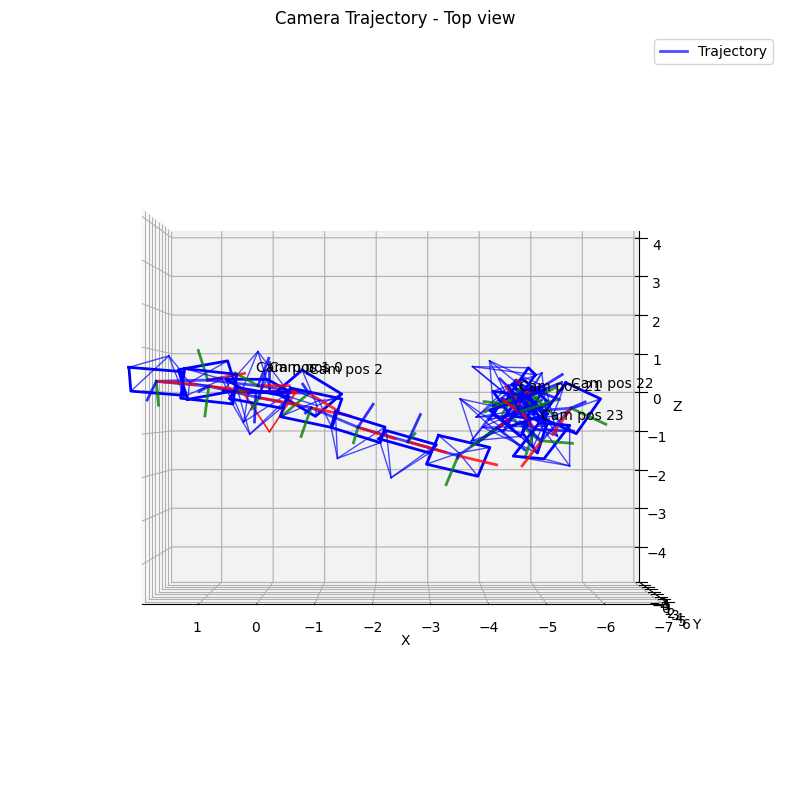

In [16]:
K1 = np.array([[1, 0, 540],
              [0, 1, 960],
              [0, 0, 1]], dtype=np.float64)

points_K_1 = compute_essential_matrices_and_poses(fundamental_results, K1)

c1 = plot_essential_matrix_poses(points_K_1, save=False)

This was bound to happen as fx=fy=1, because these focal length are too small to represent real camera characteristics

## K matrix, fx=fy=1000

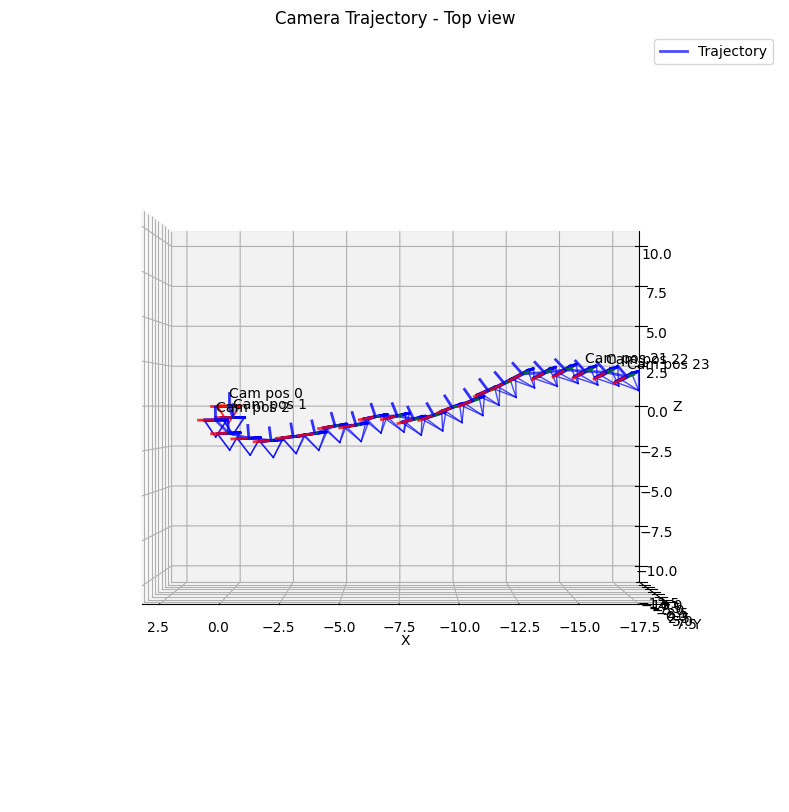

In [17]:
K2 = np.array([[1000, 0, 540],
              [0, 1000, 960],
              [0, 0, 1]], dtype=np.float64)

points_K_1000 = compute_essential_matrices_and_poses(fundamental_results, K2)

c1000 = plot_essential_matrix_poses(points_K_1000, save=False)

## K matrix, calculated from colmap

reconstructed K matrix:
[[1.70777391e+03 0.00000000e+00 5.40000000e+02]
 [0.00000000e+00 1.70777391e+03 9.60000000e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]


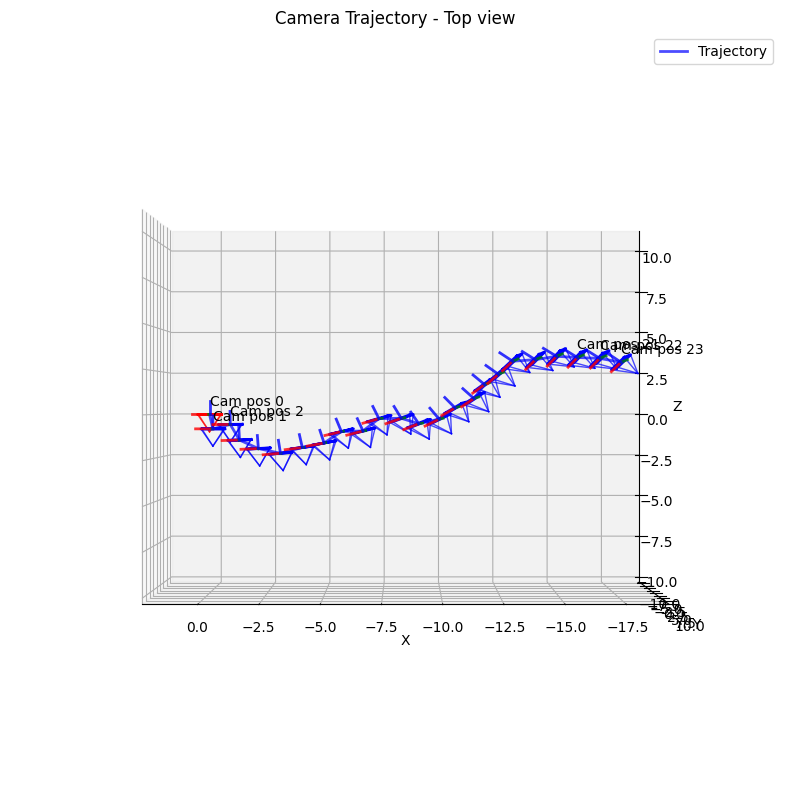

In [50]:
def read_colmap(cameras_txt_path):
    """Read SIMPLE_RADIAL camera intrinsics from COLMAP cameras.txt"""
    cameras = {}
    
    with open(cameras_txt_path, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
                
            parts = line.strip().split()
            camera_id = int(parts[0])
            model = parts[1]
            width = int(parts[2])
            height = int(parts[3])
            
            if model == "SIMPLE_RADIAL":
                # SIMPLE_RADIAL: f, cx, cy, k1
                f = float(parts[4])   # focal length (same for fx, fy)
                cx = float(parts[5])  # principal point x
                cy = float(parts[6])  # principal point y
                k1 = float(parts[7])  # radial distortion (ignore for now)
                
                K = np.array([[f, 0, cx],
                             [0, f, cy], 
                             [0, 0, 1]])
                
                cameras[camera_id] = {
                    'K': K, 
                    'distortion': k1,
                    'resolution': (width, height)
                }
                
                # print(f"Camera {camera_id}: f={f:.1f}, cx={cx}, cy={cy}, k1={k1:.4f}")
                
    return cameras

cameras = read_colmap("colmap_project/sparse/0/cameras.txt")
K_matrices = [cam['K'] for cam in cameras.values()]
K_reconstructed = np.mean(K_matrices, axis=0)
print("reconstructed K matrix:")
print(K_reconstructed)

points_K_reconstructed = compute_essential_matrices_and_poses(fundamental_results, K_reconstructed)

camera_poses = plot_essential_matrix_poses(points_K_reconstructed, save=True)

## save plots

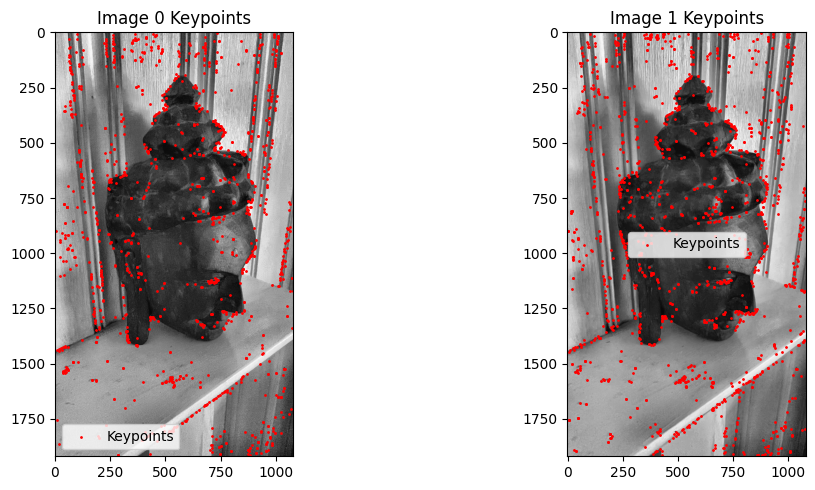

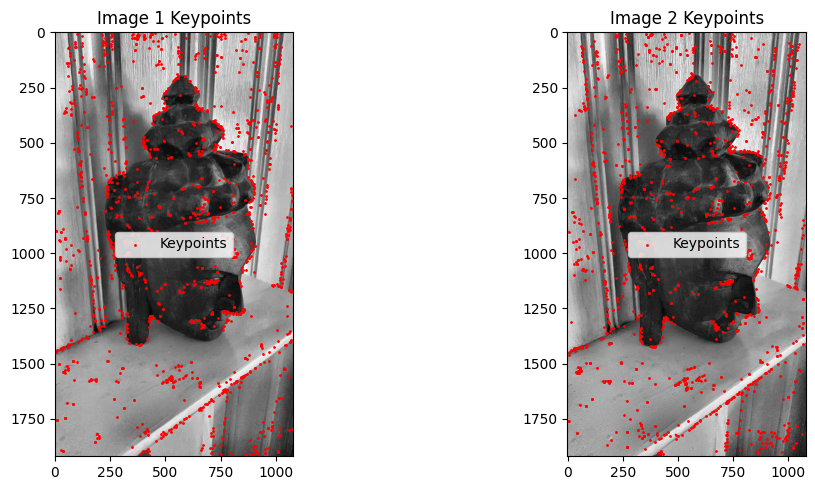

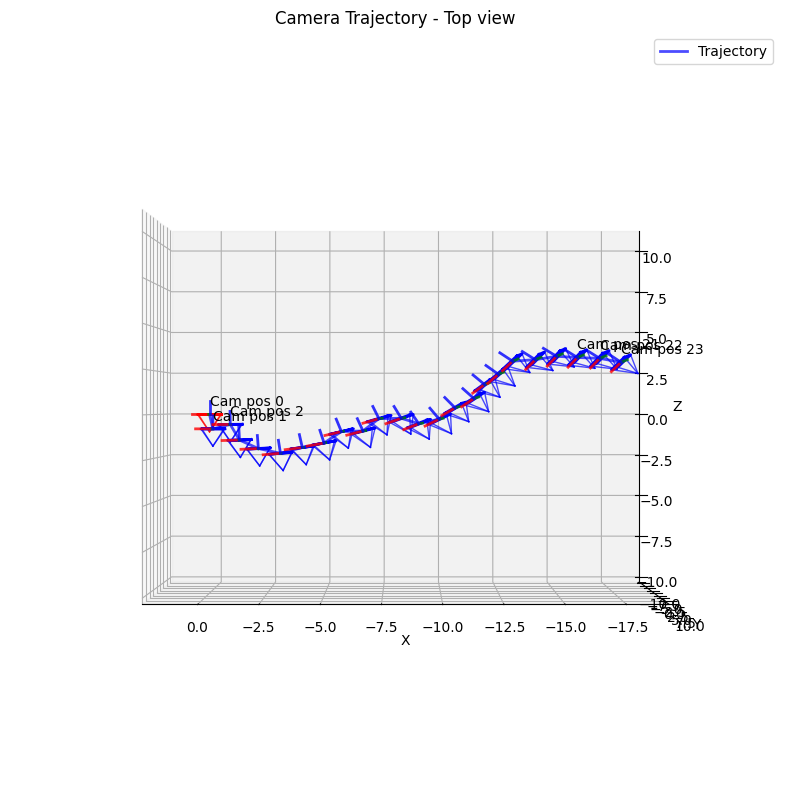

In [59]:
plot_features_and_roi(points_K_reconstructed, image_data)
_ = plot_essential_matrix_poses(points_K_reconstructed)
draw_all_epipolar_lines(points_K_reconstructed, image_data)

In [ ]:
def plot(points_3d, camera_positions=None):

    # 3D scatter plot
    fig = go.Figure()
    
    # Add 3D points
    fig.add_trace(go.Scatter3d(
        x=points_3d[:, 0],
        y=points_3d[:, 1], 
        z=points_3d[:, 2],
        mode='markers',
        marker=dict(
            size=2,
            color=points_3d[:, 2],  # Color by depth
            colorscale='Viridis',
            opacity=0.8
        ),
        name='3D Points'
    ))
    
    # Add camera positions if provided
    if camera_positions is not None:
        fig.add_trace(go.Scatter3d(
            x=camera_positions[:, 0],
            y=camera_positions[:, 1],
            z=camera_positions[:, 2],
            mode='markers+lines',
            marker=dict(size=8, color='red', symbol='diamond'),
            line=dict(color='red', width=4),
            name='Camera Trajectory'
        ))
    
    # update layout
    fig.update_layout(
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='cube', 
            xaxis=dict(autorange="reversed"), 
            yaxis=dict(autorange="reversed"), 
            zaxis=dict(autorange="reversed")
        ),
        width=1000,
        height=800
    )
    fig.show()


## Part 2 - Triangulation of matches for 3D structure

In [21]:
for i, pair_data in enumerate(points_K_reconstructed):
    pair = pair_data['pair']
    inliers = pair_data['inliers']
    kp1 = pair_data['kp1']
    kp2 = pair_data['kp2']
    
    # Calculate average motion
    motions = []
    for match in inliers:
        pt1 = np.array(kp1[match.queryIdx].pt)
        pt2 = np.array(kp2[match.trainIdx].pt)
        motion = np.linalg.norm(pt2 - pt1)
        motions.append(motion)
    
    avg_motion = np.mean(motions) if motions else 0
    
    print(f"Pair {pair}: {len(inliers)} inliers, {avg_motion:.1f} px motion")

Pair (0, 1): 220 inliers, 2.6 px motion
Pair (1, 2): 152 inliers, 8.6 px motion
Pair (2, 3): 119 inliers, 38.8 px motion
Pair (3, 4): 46 inliers, 76.7 px motion
Pair (4, 5): 53 inliers, 51.1 px motion
Pair (5, 6): 86 inliers, 14.7 px motion
Pair (6, 7): 72 inliers, 19.4 px motion
Pair (7, 8): 58 inliers, 64.4 px motion
Pair (8, 9): 68 inliers, 24.3 px motion
Pair (9, 10): 78 inliers, 37.1 px motion
Pair (10, 11): 84 inliers, 35.3 px motion
Pair (11, 12): 90 inliers, 76.8 px motion
Pair (12, 13): 59 inliers, 57.8 px motion
Pair (13, 14): 67 inliers, 91.5 px motion
Pair (14, 15): 78 inliers, 35.7 px motion
Pair (15, 16): 98 inliers, 25.0 px motion
Pair (16, 17): 127 inliers, 38.8 px motion
Pair (17, 18): 125 inliers, 22.3 px motion
Pair (18, 19): 101 inliers, 55.6 px motion
Pair (19, 20): 135 inliers, 29.2 px motion
Pair (20, 21): 130 inliers, 61.1 px motion
Pair (21, 22): 140 inliers, 50.9 px motion
Pair (22, 23): 123 inliers, 91.2 px motion


In the above, I am trying to determine which camera pair would be best for triangulation, considering both the number of inliers and the movement between the pair of cameras. This helps ensure that the triangulated 3D points are accurate and reliable.

### PNP 


Pair (0, 1): 219 inliers, 2.6 px motion

Pair (1, 2): 158 inliers, 10.7 px motion

Pair (2, 3): 119 inliers, 39.2 px motion

I attempt to initialize with the 14th and 15th cameras instead, and then proceed with incremental PnP around them, which helps provide better camera movement and more accurate results.

In [ ]:
def triangulate_point_dlt(P1, P2, pt1, pt2):
    """Triangulate single point - DLT method"""
    pt1 = pt1.flatten()
    pt2 = pt2.flatten()
    
    A = np.array([
        pt1[0] * P1[2, :] - P1[0, :],
        pt1[1] * P1[2, :] - P1[1, :],
        pt2[0] * P2[2, :] - P2[0, :],
        pt2[1] * P2[2, :] - P2[1, :]
    ])
    
    _, _, Vt = np.linalg.svd(A)
    X = Vt[-1]
    return X

def is_point_valid(point_3d, R1, t1, R2, t2, min_depth=0.1, max_depth=100, max_xy=50):
    """Checking if the triangulated point is valid"""
    depth1 = (R1 @ point_3d + t1)[2]
    depth2 = (R2 @ point_3d + t2)[2]
    
    if depth1 <= min_depth or depth2 <= min_depth:
        return False
    
    if point_3d[2] <= min_depth or point_3d[2] >= max_depth:
        return False
    
    if abs(point_3d[0]) >= max_xy or abs(point_3d[1]) >= max_xy:
        return False
    
    return True

def find_initialization_pair(points_K_reconstructed, cam1_id=2, cam2_id=3):
    """Get the Camera pair for initialization"""
    for i, pair_data in enumerate(points_K_reconstructed):
        pair = pair_data['pair']
        if pair == (cam1_id, cam2_id) or pair == (cam2_id, cam1_id):
            print(f"Initialization pair: {pair} with {len(pair_data['inliers'])} inliers")
            return i
    
    print("Could not find pair")
    return None

def triangulate_points_batch(R1, t1, R2, t2, kp1, kp2, matches, K):
    P1 = K @ np.hstack([R1, t1.reshape(-1, 1)])
    P2 = K @ np.hstack([R2, t2.reshape(-1, 1)])
    
    points_3d = []
    valid_matches = []
    
    for match in matches:
        pt1 = np.array(kp1[match.queryIdx].pt).reshape(2, 1)
        pt2 = np.array(kp2[match.trainIdx].pt).reshape(2, 1)
        
        point_4d = triangulate_point_dlt(P1, P2, pt1, pt2)
        
        if abs(point_4d[3]) < 1e-8:
            continue
        
        point_3d = point_4d[:3] / point_4d[3]
        
        if is_point_valid(point_3d, R1, t1, R2, t2):
            points_3d.append(point_3d)
            valid_matches.append(match)
    
    return np.array(points_3d), valid_matches

def initialize_reconstruction(points_K_reconstructed, K, cam1_id=2, cam2_id=3):
    """Initialize reconstruction with specific camera pair"""
    init_pair_idx = find_initialization_pair(points_K_reconstructed, cam1_id, cam2_id)
    
    if init_pair_idx is None:
        raise ValueError(f"Could not find pair ({cam1_id}, {cam2_id})")
    
    pair_data = points_K_reconstructed[init_pair_idx]
    init_pair = pair_data['pair']
    
    # Ensure cam1_id is actually first
    if init_pair[0] != cam1_id:
        cam1_id, cam2_id = cam2_id, cam1_id
    
    # First camera at origin
    R1, t1 = np.eye(3), np.zeros(3)
    
    # Second camera from essential matrix
    R2 = pair_data['R']
    t2 = pair_data['t'].flatten() if hasattr(pair_data['t'], 'flatten') else np.array(pair_data['t']).flatten()
    
    # Handle swapped pairs
    if init_pair[0] == cam1_id:
        kp1 = pair_data['kp1']
        kp2 = pair_data['kp2']
    else:
        kp1 = pair_data['kp2']
        kp2 = pair_data['kp1']
    
    inliers = pair_data['inliers']
    
    points_3d_coords, valid_matches = triangulate_points_batch(R1, t1, R2, t2, kp1, kp2, inliers, K)
    
    # Initialize cameras
    cameras = {
        cam1_id: {'R': R1, 't': t1, 'keypoints': kp1},
        cam2_id: {'R': R2, 't': t2, 'keypoints': kp2}
    }
    
    # Initialize 3D points with observations
    points_3d = {}
    for i, (point_3d, match) in enumerate(zip(points_3d_coords, valid_matches)):
        points_3d[i] = {
            'coords': point_3d,
            'observations': {
                cam1_id: match.queryIdx,
                cam2_id: match.trainIdx
            }
        }
    
    print(f"Initialized with cameras {cam1_id}, {cam2_id} - {len(points_3d)} points")
    
    return cameras, points_3d, (cam1_id, cam2_id)

def find_2d_3d_correspondences(points_3d, new_cam_id, connecting_pair_data, existing_cam_id):
    """Find 2D-3D correspondences """
    correspondences_2d = []
    correspondences_3d = []
    point_ids = []
    
    pair = connecting_pair_data['pair']
    
    if pair[0] == existing_cam_id and pair[1] == new_cam_id:
 
        new_keypoints = connecting_pair_data['kp2']
        forward_direction = True
    elif pair[0] == new_cam_id and pair[1] == existing_cam_id:

        new_keypoints = connecting_pair_data['kp1']
        forward_direction = False
    else:
        return [], [], [], None
    
    inliers = connecting_pair_data['inliers']
    
    for match in inliers:
        if forward_direction:
            existing_kp_idx = match.queryIdx
            new_kp_idx = match.trainIdx
        else:
            existing_kp_idx = match.trainIdx  
            new_kp_idx = match.queryIdx
        
        for point_id, point_data in points_3d.items():
            if existing_cam_id in point_data['observations']:
                if point_data['observations'][existing_cam_id] == existing_kp_idx:
                    correspondences_3d.append(point_data['coords'])
                    correspondences_2d.append(new_keypoints[new_kp_idx].pt)
                    point_ids.append(point_id)
                    break
    
    return correspondences_2d, correspondences_3d, point_ids, new_keypoints

def solve_pnp_ransac(correspondences_3d, correspondences_2d, K, distCoeffs, 
                     iterationsCount=1000, reprojectionError=2.0, confidence=0.99):
    """PnP RANSAC implementation"""
    if len(correspondences_3d) < 6:
        return False, None, None, None
    
    n_points = len(correspondences_3d)
    best_inliers = []
    best_rvec = None
    best_tvec = None
    max_inliers = 0
    
    for _ in range(iterationsCount):
        sample_indices = np.random.choice(n_points, 6, replace=False)
        sample_3d = correspondences_3d[sample_indices]
        sample_2d = correspondences_2d[sample_indices]
        
        try:
            success, rvec, tvec = cv2.solvePnP(sample_3d, sample_2d, K, distCoeffs)
            if not success:
                continue
        except:
            continue
        
        projected_points, _ = cv2.projectPoints(correspondences_3d, rvec, tvec, K, distCoeffs)
        projected_points = projected_points.reshape(-1, 2)
        errors = np.linalg.norm(projected_points - correspondences_2d, axis=1)
        
        inlier_mask = errors < reprojectionError
        current_inliers = np.where(inlier_mask)[0]
        
        if len(current_inliers) > max_inliers:
            max_inliers = len(current_inliers)
            best_inliers = current_inliers
            best_rvec = rvec.copy()
            best_tvec = tvec.copy()
            
            inlier_ratio = len(current_inliers) / n_points
            if inlier_ratio > confidence:
                break
    
    if max_inliers >= 6:
        try:
            inlier_3d = correspondences_3d[best_inliers]
            inlier_2d = correspondences_2d[best_inliers]
            
            success, refined_rvec, refined_tvec = cv2.solvePnP(inlier_3d, inlier_2d, K, distCoeffs)
            if success:
                best_rvec = refined_rvec
                best_tvec = refined_tvec
            
            return True, best_rvec, best_tvec, best_inliers.reshape(-1, 1)
        except:
            return False, None, None, None
    
    return False, None, None, None

def add_camera_with_pnp(cameras, points_3d, points_K_reconstructed, new_cam_id, K):
    """Add a new camera using PnP"""
    best_connection = None
    max_correspondences = 0
    
    for existing_cam_id in cameras.keys():
        connecting_pair = None
        
        for pair_data in points_K_reconstructed:
            pair = pair_data['pair']
            
            if (pair[0] == existing_cam_id and pair[1] == new_cam_id) or \
               (pair[0] == new_cam_id and pair[1] == existing_cam_id):
                connecting_pair = pair_data
                break
        
        if connecting_pair is None:
            continue
        
        correspondences_2d, correspondences_3d, point_ids, new_keypoints = find_2d_3d_correspondences(
            points_3d, new_cam_id, connecting_pair, existing_cam_id
        )
        
        if len(correspondences_2d) > max_correspondences:
            max_correspondences = len(correspondences_2d)
            best_connection = {
                'existing_cam': existing_cam_id,
                'correspondences_2d': correspondences_2d,
                'correspondences_3d': correspondences_3d,
                'point_ids': point_ids,
                'new_keypoints': new_keypoints,
                'pair_data': connecting_pair
            }
    
    if not best_connection or max_correspondences < 6:
        return False
    
    correspondences_3d = np.array(best_connection['correspondences_3d'], dtype=np.float32)
    correspondences_2d = np.array(best_connection['correspondences_2d'], dtype=np.float32)
    
    success, rvec, tvec, inliers = solve_pnp_ransac(
        correspondences_3d, correspondences_2d, K, None,
        iterationsCount=1000, reprojectionError=2.0
    )
    
    if not success:
        return False
    
    R, _ = cv2.Rodrigues(rvec)
    t = tvec.flatten()
    
    cameras[new_cam_id] = {
        'R': R,
        't': t,
        'keypoints': best_connection['new_keypoints']
    }
    
    if inliers is not None:
        inlier_indices = inliers.flatten()
        for idx in inlier_indices:
            if idx < len(best_connection['point_ids']):
                point_id = best_connection['point_ids'][idx]
                
                pair_data = best_connection['pair_data']
                for i, match in enumerate(pair_data['inliers']):
                    if i == idx:
                        if pair_data['pair'][0] == best_connection['existing_cam']:
                            match_idx = match.trainIdx
                        else:
                            match_idx = match.queryIdx
                        
                        points_3d[point_id]['observations'][new_cam_id] = match_idx
                        break
    
    return True

def triangulate_new_points(cameras, points_3d, points_K_reconstructed, K, recent_only=False):
    """Triangulate new 3D points from newly added cameras"""
    max_point_id = max(points_3d.keys()) if points_3d else -1
    
    if recent_only:
        cams_to_check = list(cameras.keys())[-3:]
    else:
        cams_to_check = list(cameras.keys())
    
    for cam1_id in cams_to_check:
        for cam2_id in cameras.keys():
            if cam1_id >= cam2_id:
                continue
            
            pair_data = None
            kp1, kp2, inliers = None, None, None
            
            for pair_info in points_K_reconstructed:
                pair = pair_info['pair']
                if pair == (cam1_id, cam2_id):
                    pair_data = pair_info
                    kp1, kp2 = pair_data['kp1'], pair_data['kp2']
                    inliers = pair_data['inliers']
                    break
                elif pair == (cam2_id, cam1_id):
                    pair_data = pair_info
                    kp1, kp2 = pair_data['kp2'], pair_data['kp1']
                    inliers = [cv2.DMatch(m.trainIdx, m.queryIdx, m.distance) for m in pair_data['inliers']]
                    break
            
            if pair_data is None:
                continue
            
            R1, t1 = cameras[cam1_id]['R'], cameras[cam1_id]['t']
            R2, t2 = cameras[cam2_id]['R'], cameras[cam2_id]['t']
            
            P1 = K @ np.hstack([R1, t1.reshape(-1, 1)])
            P2 = K @ np.hstack([R2, t2.reshape(-1, 1)])
            
            for match in inliers:
                kp1_idx = match.queryIdx
                kp2_idx = match.trainIdx
                
                already_exists = False
                for point_data in points_3d.values():
                    if (cam1_id in point_data['observations'] and 
                        point_data['observations'][cam1_id] == kp1_idx):
                        point_data['observations'][cam2_id] = kp2_idx
                        already_exists = True
                        break
                
                if not already_exists:
                    pt1 = np.array(kp1[kp1_idx].pt)
                    pt2 = np.array(kp2[kp2_idx].pt)
                    
                    X = triangulate_point_dlt(P1, P2, pt1, pt2)
                    
                    if abs(X[3]) > 1e-8:
                        point_3d = X[:3] / X[3]
                        
                        if is_point_valid(point_3d, R1, t1, R2, t2):
                            points_3d[max_point_id + 1] = {
                                'coords': point_3d,
                                'observations': {
                                    cam1_id: kp1_idx,
                                    cam2_id: kp2_idx
                                }
                            }
                            max_point_id += 1

def extract_results_for_plotting(cameras, points_3d):
    """Extract camera positions and 3D points for visualization"""
    camera_positions = []
    for cam_id in sorted(cameras.keys()):
        R, t = cameras[cam_id]['R'], cameras[cam_id]['t']
        center = -R.T @ t
        camera_positions.append(center)
    
    camera_positions = np.array(camera_positions)
    points_array = np.array([point['coords'] for point in points_3d.values()])
    
    print(f"Extracted {len(camera_positions)} cameras, {len(points_array)} points")
    
    return points_array, camera_positions

def run_pnp_incremental_sfm(points_K_reconstructed, K, init_cameras=[2, 3], camera_sequence=None, aggressive_triangulation=True, max_rounds=5):
    """Run incremental Structure from Motion with PnP"""
    
    # Initialize with specified camera pair
    cameras, points_3d, init_pair = initialize_reconstruction(
        points_K_reconstructed, K, init_cameras[0], init_cameras[1]
    )
    
    successful_cameras = set(cameras.keys())
    
    if camera_sequence is None:
        all_cameras = set(range(24))
        remaining_cameras = sorted(all_cameras - successful_cameras)
    else:
        remaining_cameras = [c for c in camera_sequence if c not in successful_cameras]
    
    print(f"Camera sequence: {remaining_cameras}")
    
    # Multiple tries to retry failed cameras
    for round_num in range(max_rounds):
        if not remaining_cameras:
            break
            
        print(f"\n=== Round {round_num + 1} ===")
        cameras_added = []
        failed = []
        
        for new_cam_id in remaining_cameras:
            success = add_camera_with_pnp(cameras, points_3d, points_K_reconstructed, new_cam_id, K)
            if success:
                successful_cameras.add(new_cam_id)
                cameras_added.append(new_cam_id)
                
                triangulate_new_points(cameras, points_3d, points_K_reconstructed, K, 
                                     recent_only=not aggressive_triangulation)
                print(f"  Camera {new_cam_id} added - {len(points_3d)} total points")
            else:
                failed.append(new_cam_id)
        
        print(f"Round {round_num + 1}: {len(cameras_added)} added, {len(failed)} failed")
        
        remaining_cameras = failed
        
        if not cameras_added:
            print("stopping.")
            break

    print("RECONSTRUCTION COMPLETE")
    print(f"Successful: {sorted(successful_cameras)}")
    if remaining_cameras:
        print(f"Failed: {remaining_cameras}")
    print(f"Total: {len(successful_cameras)} cameras, {len(points_3d)} points")
    
    return cameras, points_3d

# running it
cameras, points_3d = run_pnp_incremental_sfm(
    points_K_reconstructed, 
    K_reconstructed, 
    init_cameras=[14, 15],
    camera_sequence=list([16, 17, 18, 19, 20, 21, 22, 23, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]),
    aggressive_triangulation=True,
    max_rounds=10
)

final_points_3d, final_camera_poses = extract_results_for_plotting(cameras, points_3d)


Initialization pair: (14, 15) with 78 inliers
Initialized with cameras 14, 15 - 78 points
Camera sequence: [16, 17, 18, 19, 20, 21, 22, 23, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]

=== Round 1 ===
  Camera 16 added - 145 total points
  Camera 17 added - 230 total points
  Camera 18 added - 298 total points
  Camera 19 added - 353 total points
  Camera 20 added - 441 total points
  Camera 21 added - 518 total points
  Camera 22 added - 603 total points
  Camera 23 added - 659 total points
  Camera 13 added - 711 total points
  Camera 12 added - 759 total points
  Camera 11 added - 832 total points
  Camera 10 added - 902 total points
  Camera 9 added - 964 total points
  Camera 8 added - 1015 total points
  Camera 7 added - 1064 total points
  Camera 6 added - 1121 total points
  Camera 5 added - 1195 total points
  Camera 4 added - 1235 total points
  Camera 3 added - 1273 total points
  Camera 2 added - 1373 total points
  Camera 1 added - 1485 total points
  Camera 0 added - 16

In [42]:
plot(final_points_3d, final_camera_poses)

# BA in GTSAM

### since we initialized with 13 14 pair, we need to readjust these for having them sequential 

In [ ]:
# create mapping from original cam_id to sequential id
cam_id_mapping = {old_id: new_id for new_id, old_id in enumerate(sorted(cameras.keys()))}
print("Camera ID mapping:", cam_id_mapping)

# remapping cameras
remapped_cameras = {}
for old_id, new_id in cam_id_mapping.items():
    remapped_cameras[new_id] = cameras[old_id]

# remap observations in points_3d
remapped_points_3d = {}
for point_id, point_data in points_3d.items():
    remapped_obs = {}
    for old_cam_id, kp_idx in point_data['observations'].items():
        if old_cam_id in cam_id_mapping:
            remapped_obs[cam_id_mapping[old_cam_id]] = kp_idx
    
    # keep points that have observations in remapped cameras
    if len(remapped_obs) > 0:
        remapped_points_3d[point_id] = {
            'coords': point_data['coords'],
            'observations': remapped_obs
        }

print(f"Remapped cameras: {sorted(remapped_cameras.keys())}")
print(f"Remapped points: {len(remapped_points_3d)}")

Camera ID mapping: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23}
Remapped cameras: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Remapped points: 1610


### Noise modelling

In [ ]:
# factor graph
graph = gtsam.NonlinearFactorGraph()
initial_values = gtsam.Values()

# prior on first camera
prior_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.01, 0.01, 0.01, 0.01, 0.01, 0.01]))
first_cam_id = 0
first_R = gtsam.Rot3(remapped_cameras[first_cam_id]['R'])
first_t = remapped_cameras[first_cam_id]['t']
first_pose = gtsam.Pose3(first_R, first_t)
graph.add(gtsam.PriorFactorPose3(first_cam_id, first_pose, prior_noise))

print(f"Added prior on camera {first_cam_id} to anchor reconstruction")

# camera intrinsics
K_gtsam = gtsam.Cal3_S2(K_reconstructed[0,0], K_reconstructed[1,1], 
                        K_reconstructed[0,1], K_reconstructed[0,2], K_reconstructed[1,2])

# add camera poses to initial values
for cam_id in remapped_cameras.keys():
    R = gtsam.Rot3(remapped_cameras[cam_id]['R'])
    t = remapped_cameras[cam_id]['t']
    pose = gtsam.Pose3(R, t)
    initial_values.insert(cam_id, pose)

# Add 3D points to initial values
for point_id in remapped_points_3d.keys():
    point = gtsam.Point3(remapped_points_3d[point_id]['coords'])
    initial_values.insert(point_id + 1000, point)

# Add observation factors with adaptive noise based on number of observations
for point_id, point_data in remapped_points_3d.items():
    num_observations = len(point_data['observations'])
    
    # More observations = more confident = tighter noise
    if num_observations >= 4:
        point_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([1.0, 1.0]))
    elif num_observations == 3:
        point_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([1.5, 1.5]))
    else:  # 2 observations
        point_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([2.0, 2.0]))
    
    for cam_id, kp_idx in point_data['observations'].items():
        kp = remapped_cameras[cam_id]['keypoints'][kp_idx].pt
        measurement = gtsam.Point2(kp[0], kp[1])
        factor = gtsam.GenericProjectionFactorCal3_S2(
            measurement, point_noise, cam_id, point_id + 1000, K_gtsam)
        graph.add(factor)

print(f"Graph has {graph.size()} factors")
print(f"Initial values has {initial_values.size()} variables")

# Check initial error
initial_error = graph.error(initial_values)
print(f"Initial error: {initial_error:.2f}")

# Optimize with Levenberg-Marquardt
print("\nRunning bundle adjustment...")
params = gtsam.LevenbergMarquardtParams()
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial_values, params)
result = optimizer.optimize()

final_error = graph.error(result)
print(f"Final error: {final_error:.2f}")
print("Bundle adjustment complete!")

# extract optimized results
optimized_cameras = {}
optimized_points = []

for cam_id in remapped_cameras.keys():
    optimized_pose = result.atPose3(cam_id)
    optimized_cameras[cam_id] = {
        'R': optimized_pose.rotation().matrix(),
        't': np.array(optimized_pose.translation())
    }

for point_id in remapped_points_3d.keys():
    optimized_point = result.atPoint3(point_id + 1000)
    optimized_points.append(np.array(optimized_point))

optimized_points = np.array(optimized_points)
optimized_camera_positions = np.array([optimized_cameras[i]['t'] for i in sorted(optimized_cameras.keys())])


initial_avg_error = np.sqrt(graph.error(initial_values) / graph.size())
final_avg_error = np.sqrt(graph.error(result) / graph.size())   

print(f"Average reprojection error:")
print(f"Initial: {initial_avg_error:.2f} pixels")  
print(f"Final: {final_avg_error:.2f} pixels")

# Movement analysis
camera_movement = np.linalg.norm(optimized_camera_positions - final_camera_poses, axis=1)
print(f"Average camera movement: {np.mean(camera_movement):.3f}")
# Plot results
print("\nPlotting ORIGINAL reconstruction:")
plot(final_points_3d, final_camera_poses)

print("\nPlotting OPTIMIZED reconstruction:")
plot(optimized_points, optimized_camera_positions)

Added prior on camera 0 to anchor reconstruction
Graph has 4057 factors
Initial values has 1634 variables
Initial error: 299442093.89

Running bundle adjustment...
Final error: 6375733.07
Bundle adjustment complete!
Average reprojection error:
Initial: 271.68 pixels
Final: 39.64 pixels
Average camera movement: 11.019

Plotting ORIGINAL reconstruction:



Plotting OPTIMIZED reconstruction:
